# <font color='blue'>  Тестовая работа Филипповой Кристины
## <font color='green'> Т-Банк: поездки на самокатах

## <font color='green'> Цель анализа: понять поведение пользователей каршеринга, оценить влияние кешбэка и тарифов на выручку и частоту поездок, а также выделить сегменты и временные периоды с наибольшим потенциалом роста

#### Ключевые метрики
- Количество поездок на пользователя
- Выручка на пользователя и на поездку
- Объем кэшбека на пользователя и доля пользователей с кэшбеком
- Распределения по времени, регионам, сегментам пользователей

### Загрузка данных и первичный осмотр

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv('kicksharing.csv', sep=',')  

In [17]:
df.head(5)

,order_rk,party_rk,gender_cd,age,education_level_cd,marital_status_cd,lvn_state_nm,minute_cost,activation_cost,hold_amount,transport_model,distance_km,created_dttm,book_start_dttm,book_end_dttm,book_time_zone_cd,local_book_start_dttm,nominal_price_rub_amt,loyalty_accrual_rub_amt,loyalty_accrual_bns_amt
0,266071307,761067705,M,40,UGR,DIV,ТЮМЕНСКАЯ ОБЛ,4.99,30.0,300.0,SL,3.690479,2024-08-07 09:47:25.000000,2024-08-07 09:47:29.325252,2024-08-07 10:07:59.339524,5,2024-08-07 11:47:29.325252,134.79,19.48,NaN
1,355113920,614049469,F,30,GRD,MAR,РОСТОВСКАЯ ОБЛ,8.49,50.0,300.0,SL,1.114912,2024-10-17 14:57:20.000000,2024-10-17 14:57:24.586000,2024-10-17 15:04:19.419607,3,2024-10-17 14:57:24.586000,109.43,40.30,NaN
2,347424551,757583701,M,28,UGR,UNM,СВЕРДЛОВСКАЯ ОБЛ,5.99,30.0,300.0,E,1.515612,2024-09-19 05:31:41.000000,2024-09-19 05:34:59.476000,2024-09-19 05:41:50.164372,5,2024-09-19 07:34:59.476000,71.93,10.79,NaN
3,351562959,541367366,M,24,GRD,UNM,Г МОСКВА,8.99,50.0,300.0,SL,0.499411,2024-10-04 16:05:09.000000,2024-10-04 16:05:13.162000,2024-10-04 16:07:31.724918,3,2024-10-04 16:05:13.162000,76.97,7.70,NaN
4,258647149,238473615,M,34,NaN,NaN,Г МОСКВА,6.99,50.0,300.0,SL,2.602028,2024-07-10 06:57:40.000000,2024-07-10 06:57:43.017125,2024-07-10 07:07:48.446462,3,2024-07-10 06:57:43.017125,126.89,25.38,NaN


In [4]:
df.shape

(396749, 20)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396749 entries, 0 to 396748
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   order_rk                 396749 non-null  int64  
 1   party_rk                 396749 non-null  int64  
 2   gender_cd                393828 non-null  object 
 3   age                      396749 non-null  int64  
 4   education_level_cd       190059 non-null  object 
 5   marital_status_cd        217729 non-null  object 
 6   lvn_state_nm             362572 non-null  object 
 7   minute_cost              396749 non-null  float64
 8   activation_cost          396749 non-null  float64
 9   hold_amount              396749 non-null  float64
 10  transport_model          396749 non-null  object 
 11  distance_km              396749 non-null  float64
 12  created_dttm             396749 non-null  object 
 13  book_start_dttm          396749 non-null  object 
 14  book

In [6]:
df.describe()

,order_rk,party_rk,age,minute_cost,activation_cost,hold_amount,distance_km,book_time_zone_cd,nominal_price_rub_amt,loyalty_accrual_rub_amt,loyalty_accrual_bns_amt
count,3.967490e+05,3.967490e+05,396749.000000,396749.000000,396749.000000,396749.000000,396749.000000,396749.000000,396749.000000,366992.000000,21948.000000
mean,2.892236e+08,5.988426e+08,31.544006,7.288688,42.593226,299.983869,3.681031,3.536155,127.647694,37.516121,127.789319
std,3.813458e+07,3.311675e+08,9.434545,1.289492,11.989974,1.939153,141.862349,1.209075,100.122365,75.208560,496.812143
min,2.526112e+08,1.471700e+04,12.000000,1.500000,0.000000,80.000000,0.000000,0.000000,0.000000,-161.940000,1.000000
25%,2.618150e+08,2.962323e+08,24.000000,6.490000,30.000000,300.000000,0.941054,3.000000,80.840000,11.240000,43.000000
50%,2.704367e+08,6.110092e+08,31.000000,7.490000,50.000000,300.000000,1.729883,3.000000,103.940000,18.730000,62.000000
75%,3.432678e+08,8.646921e+08,37.000000,8.220000,50.000000,300.000000,3.063694,3.000000,142.100000,35.060000,81.000000
max,3.562528e+08,1.301075e+09,94.000000,19.990000,50.000000,500.000000,56012.640308,12.000000,5627.640000,3185.000000,55429.360970


In [8]:
df.isna().sum()

order_rk                        0
party_rk                        0
gender_cd                    2921
age                             0
education_level_cd         206690
marital_status_cd          179020
lvn_state_nm                34177
minute_cost                     0
activation_cost                 0
hold_amount                     0
transport_model                 0
distance_km                     0
created_dttm                    0
book_start_dttm                 0
book_end_dttm                   0
book_time_zone_cd               0
local_book_start_dttm           0
nominal_price_rub_amt           0
loyalty_accrual_rub_amt     29757
loyalty_accrual_bns_amt    374801
dtype: int64

In [9]:
df.duplicated().sum()

0

В датасете ~397 тыс. поездок без дубликатов строк, с полным набором ценовых и временных атрибутов и частично заполненными соцдем-полями (особенно образование и семейное положение), что ограничивает глубину сегментации по ним. Структура тарифов и итоговой стоимости выглядит реалистично и соответствует ожиданиям для онлайн-сервиса, но уже заметны потенциальные выбросы по цене, дистанции и показателям лояльности, которые потребуют отдельной проверки при дальнейшем исследовании и преобразовании данных.

### Преобразование типов и создание метрик

In [26]:
# Приводим даты
time_cols = ['created_dttm', 'book_start_dttm', 'book_end_dttm', 'local_book_start_dttm']
df[time_cols] = df[time_cols].apply(pd.to_datetime)

# Длительность поездки в минутах
df['ride_duration_min'] = (df['book_end_dttm'] - df['book_start_dttm']) / pd.Timedelta(minutes=1)

# Дата, час, день недели
df['ride_date'] = df['book_start_dttm'].dt.date
df['ride_hour'] = df['book_start_dttm'].dt.hour
df['ride_weekday'] = df['book_start_dttm'].dt.weekday  # 0=Пн, 6=Вс

weekday_map = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
df['weekday_name'] = df['ride_weekday'].map(weekday_map)

# Возрастные группы
bins = [0, 17, 24, 35, 45, 60, 100]
labels = ['<=17', '18-24', '25-35', '36-45', '46-60', '60+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

# Ценообразование
df['price_per_km'] = df['nominal_price_rub_amt'] / df['distance_km'].replace(0, np.nan)
df['price_per_min'] = df['nominal_price_rub_amt'] / df['ride_duration_min'].replace(0, np.nan)

# Флаг кешбэка/лояльности
df['has_cashback'] = df['loyalty_accrual_rub_amt'].fillna(0) > 0

Мы выполнили полный цикл базового фичеринга для датасета поездок такси: преобразовали колонки дат в datetime, создали метрику длительности поездки в минутах, извлекли временные фичи (дата, час, день недели), сгруппировали возраст в категории, рассчитали ключевые ценовые метрики price_per_km и price_per_min с защитой от деления на ноль, а также создали флаг лояльности по наличию кешбэка

### Проверка качества данных и выбросов

In [27]:
# Порядок событий
print((df['created_dttm'] <= df['book_start_dttm']).value_counts(normalize=True))
print((df['book_start_dttm'] <= df['book_end_dttm']).value_counts(normalize=True))

# Аномальные случаи
time_anomalies = df[(df['created_dttm'] > df['book_start_dttm']) | (df['book_start_dttm'] > df['book_end_dttm'])]
time_anomalies[['created_dttm','book_start_dttm','book_end_dttm']].head()

True     0.999982
False    0.000018
Name: proportion, dtype: float64
True    1.0
Name: proportion, dtype: float64


,created_dttm,book_start_dttm,book_end_dttm
17465,2024-08-21 20:01:45,2024-08-21 20:01:43.407348,2024-08-21 20:03:05.118341
17571,2024-08-21 19:23:33,2024-08-21 19:23:32.044664,2024-08-21 19:40:06.692699
45477,2024-08-21 19:59:16,2024-08-21 19:59:15.157343,2024-08-21 20:04:56.549535
62046,2024-08-21 19:39:29,2024-08-21 19:39:27.261084,2024-08-21 19:55:16.363350
145193,2024-08-21 19:52:09,2024-08-21 19:52:07.279284,2024-08-21 19:59:16.873692


Проверили порядок событий: 99.998% корректны, 0.002% аномалий.

In [83]:
cat_cols = ['gender_cd','education_level_cd','marital_status_cd','transport_model','has_cashback','has_loyalty']
for col in cat_cols:
    print(col)
    print(df_clean[col].value_counts())

gender_cd
gender_cd
M    297875
F     50310
Name: count, dtype: int64
education_level_cd
education_level_cd
GRD    83183
SCH    44760
UGR    34442
PGR     3786
ACD     1142
Name: count, dtype: int64
marital_status_cd
marital_status_cd
UNM    102591
MAR     64593
CIV     13190
DIV     10250
WID       609
Name: count, dtype: int64
transport_model
transport_model
SL              213776
E                61826
Max              60252
Urban E-Bike      4216
ES400             3537
ES200             2900
ES100             2329
MK                 876
ES-08S             692
Techno             200
LB                 103
ES                  94
Lucky               58
B1D                 24
Name: count, dtype: int64
has_cashback
has_cashback
True     323993
False     26890
Name: count, dtype: int64
has_loyalty
has_loyalty
True     323993
False     26890
Name: count, dtype: int64


In [84]:
print("Уникальные пользователи:", df_clean['party_rk'].nunique())
print("Уникальные модели самокатов:", df_clean['transport_model'].nunique())
print("Период данных:", df_clean['ride_date'].min(), "-", df_clean['ride_date'].max())

Уникальные пользователи: 56010
Уникальные модели самокатов: 14
Период данных: 2024-04-09 - 2024-10-21


Анализ данных Т-Банка показал, что база охватывает 56 010 уникальных пользователей за период с 9 апреля по 21 октября 2024 года. Основная часть пользователей — мужчины (≈85 %), а более половины имеют высшее образование. Большинство пользователей не состоят в браке (43 %). Из 14 моделей самокатов основную долю поездок обеспечивают три модели: SL, E и Max. Практически все поездки связаны с кешбеком и лояльностью (92 %), что делает эти переменные ключевыми для анализа пользовательской активности. Эти данные позволяют выявлять закономерности в поведении пользователей, проверять продуктовые гипотезы и строить рекомендации для повышения выручки и вовлеченности.

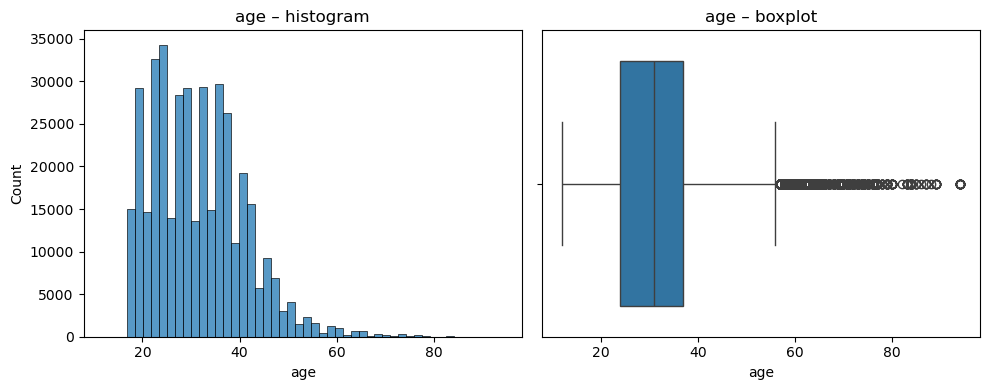

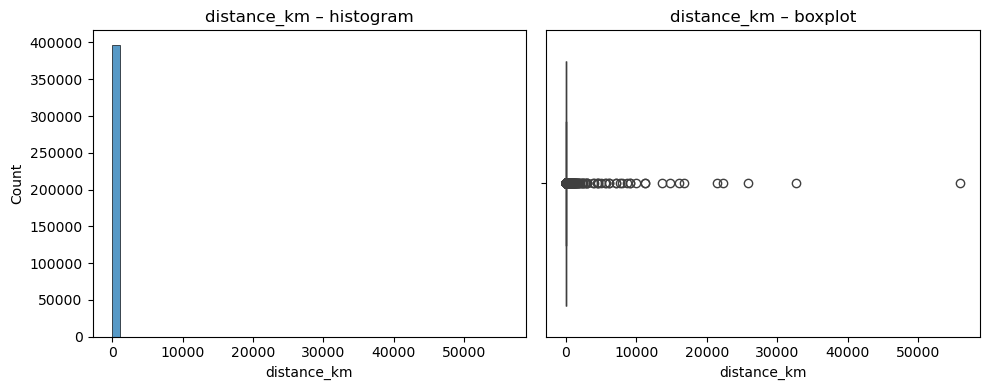

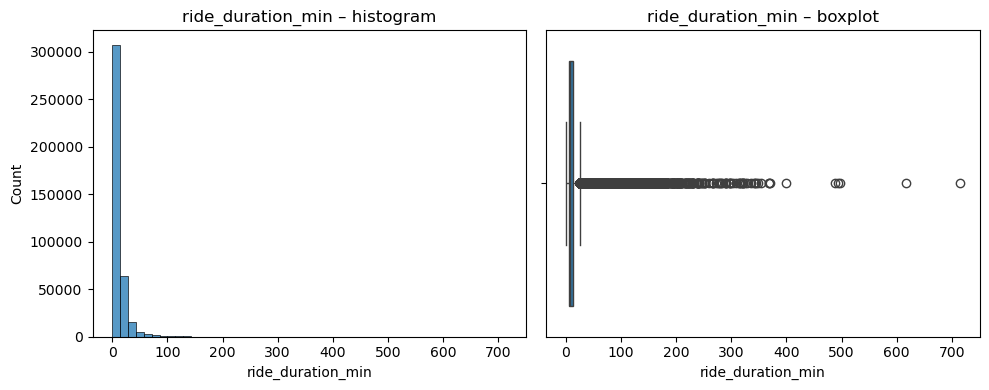

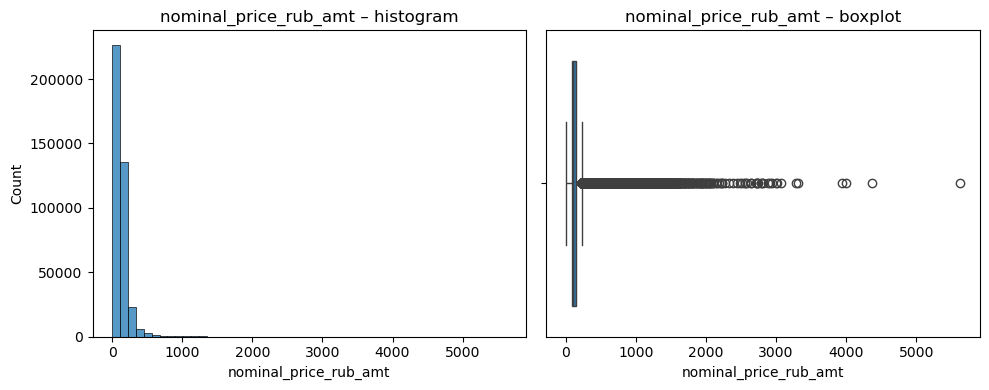

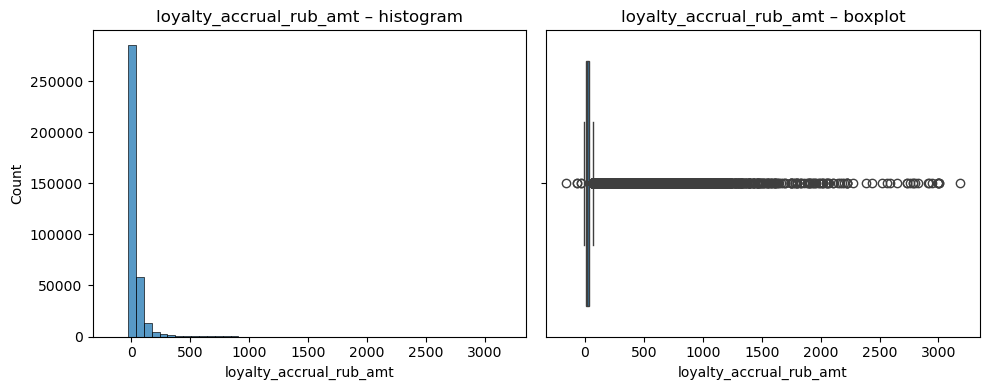

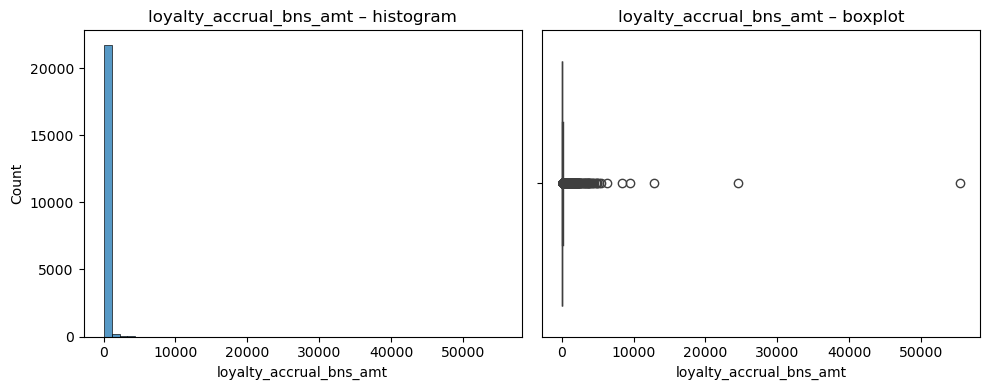

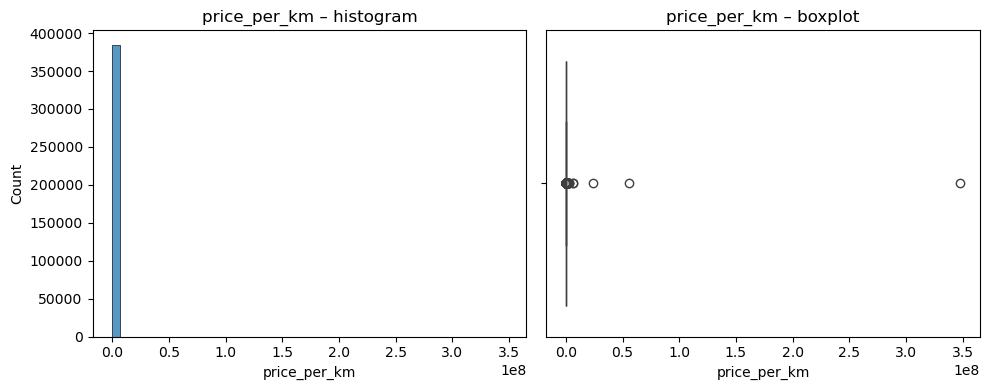

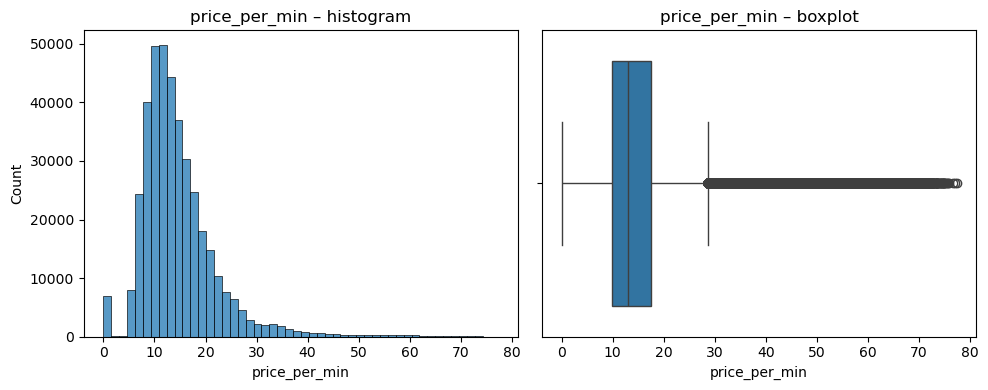

In [28]:
num_cols = [
    'age', 'distance_km', 'ride_duration_min',
    'nominal_price_rub_amt', 'loyalty_accrual_rub_amt',
    'loyalty_accrual_bns_amt', 'price_per_km', 'price_per_min'
]

for c in num_cols:
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.histplot(data=df, x=c, bins=50, kde=False)
    plt.title(f'{c} – histogram')

    plt.subplot(1,2,2)
    sns.boxplot(x=df[c])
    plt.title(f'{c} – boxplot')
    plt.tight_layout()
    plt.show()

In [31]:
# Создаем функцию для фильтрации выбросов по IQR
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[column].between(lower, upper)

# Применяем для каждой колонки отдельно
df_clean = df[
    remove_outliers_iqr(df, 'distance_km') &
    remove_outliers_iqr(df, 'nominal_price_rub_amt') &
    remove_outliers_iqr(df, 'ride_duration_min')
].copy()

# Проверяем результат
print("Размер датасета до очистки:", df.shape)
print("Размер датасета после очистки:", df_clean.shape)

Размер датасета до очистки: (396749, 29)
Размер датасета после очистки: (350883, 29)


In [34]:
for col in log_cols:
    neg_count = (df_clean[col] < 0).sum()
    print(f"{col}: отрицательных значений = {neg_count}")

distance_km: отрицательных значений = 0
nominal_price_rub_amt: отрицательных значений = 0
ride_duration_min: отрицательных значений = 0
price_per_km: отрицательных значений = 0
price_per_min: отрицательных значений = 0
loyalty_accrual_rub_amt: отрицательных значений = 1
loyalty_accrual_bns_amt: отрицательных значений = 0


In [35]:
# Заменяем отрицательные значения на 0
df_clean['loyalty_accrual_rub_amt'] = df_clean['loyalty_accrual_rub_amt'].clip(lower=0)

# Логарифмирование всех колонок
log_cols = ['distance_km', 'nominal_price_rub_amt', 'ride_duration_min',
            'price_per_km', 'price_per_min', 'loyalty_accrual_rub_amt', 'loyalty_accrual_bns_amt']

for col in log_cols:
    df_clean[f'log_{col}'] = np.log1p(df_clean[col])

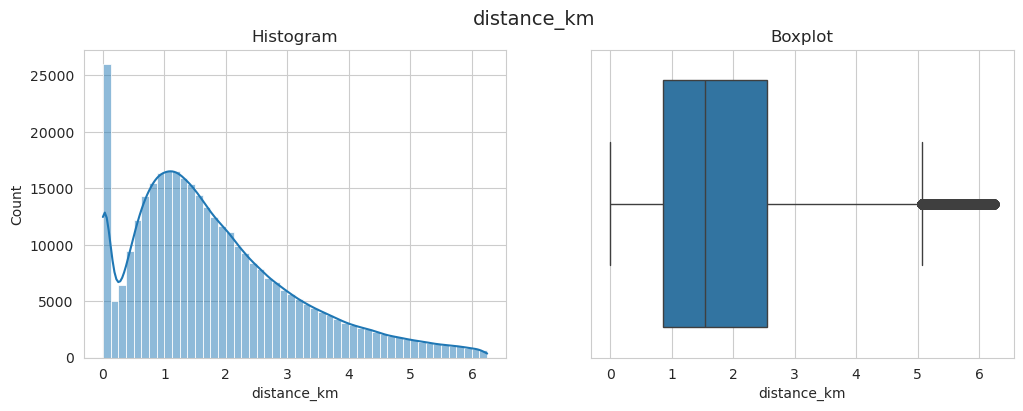

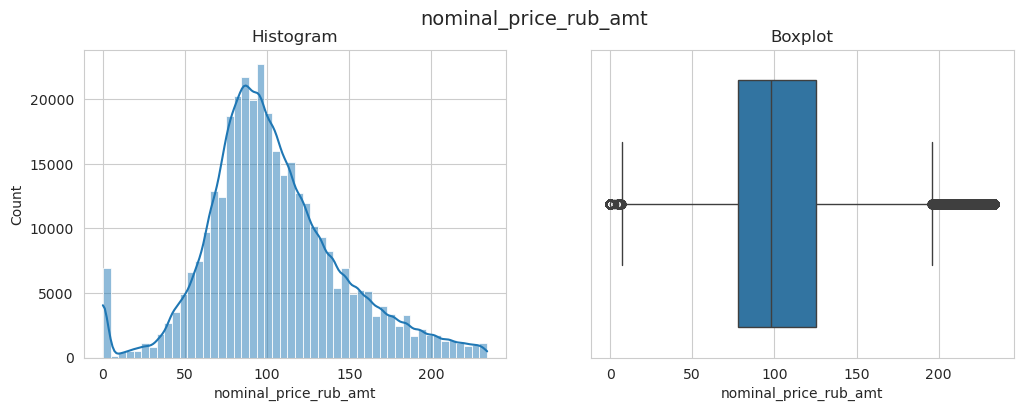

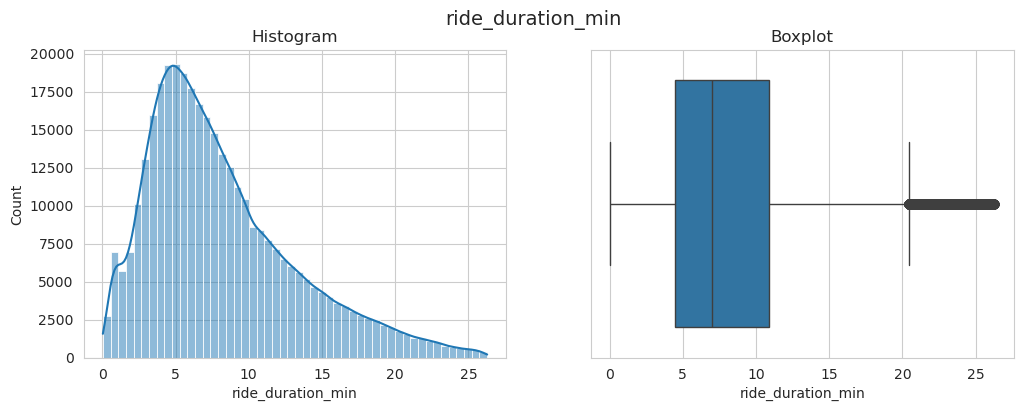

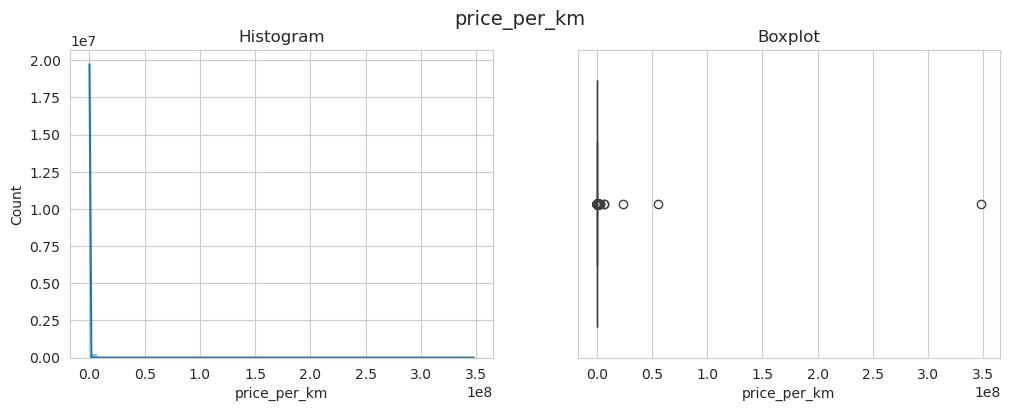

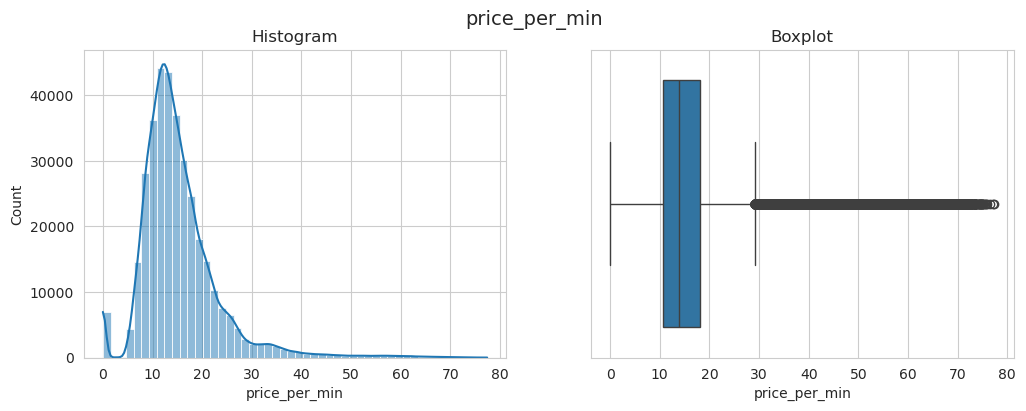

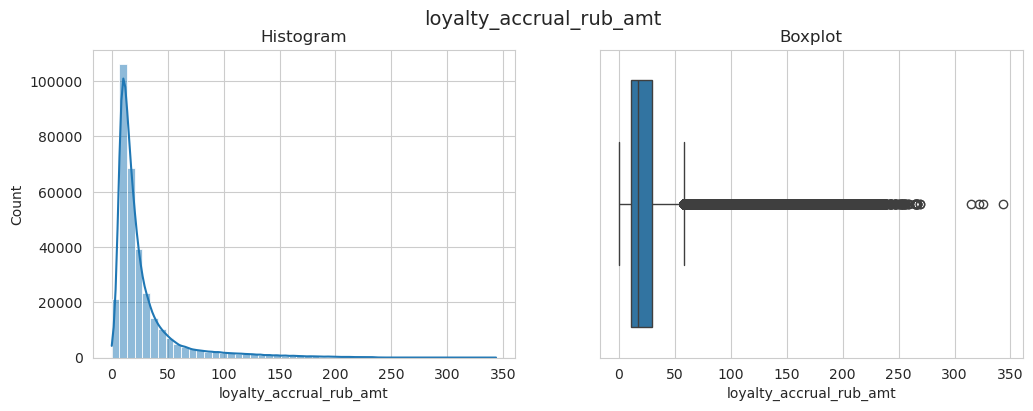

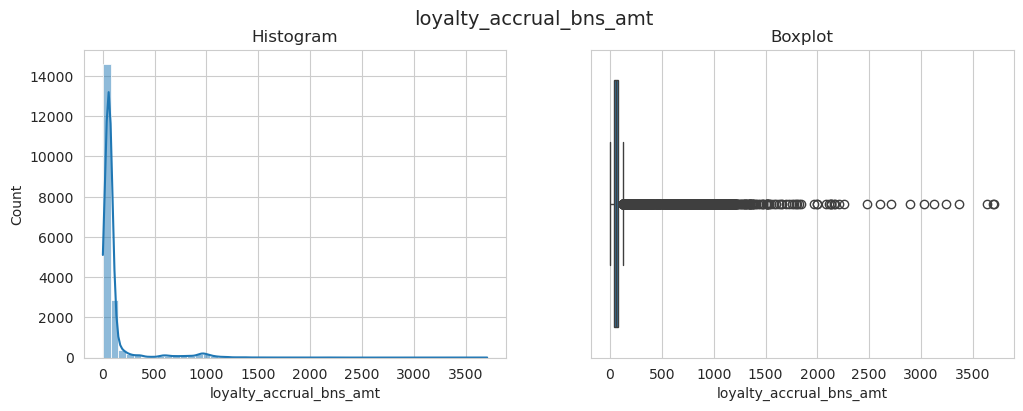

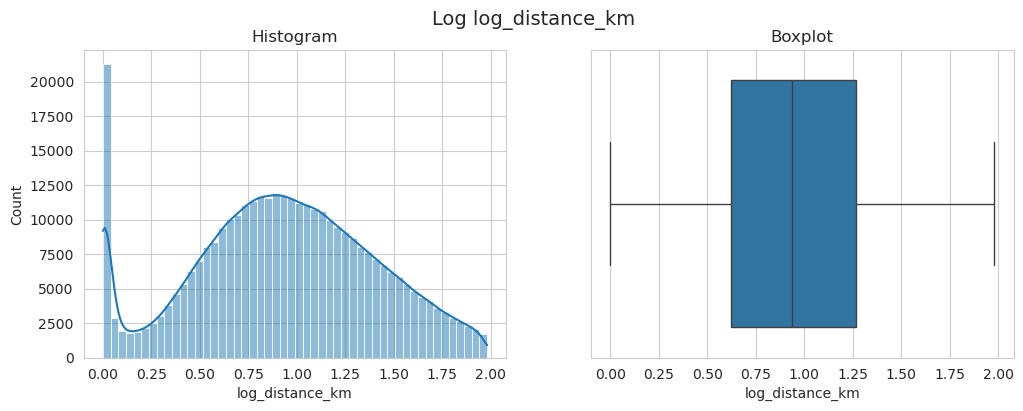

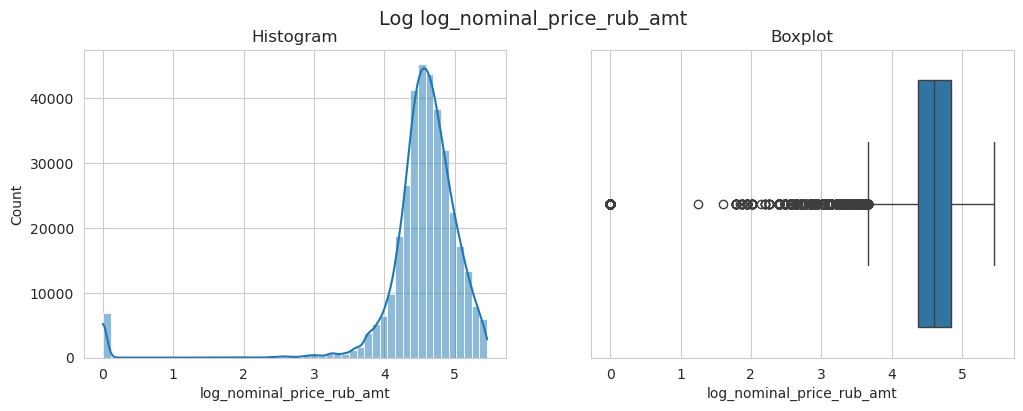

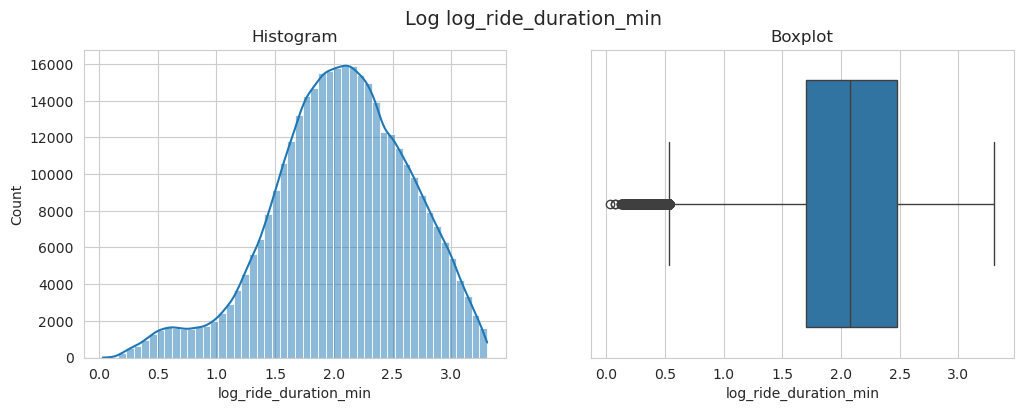

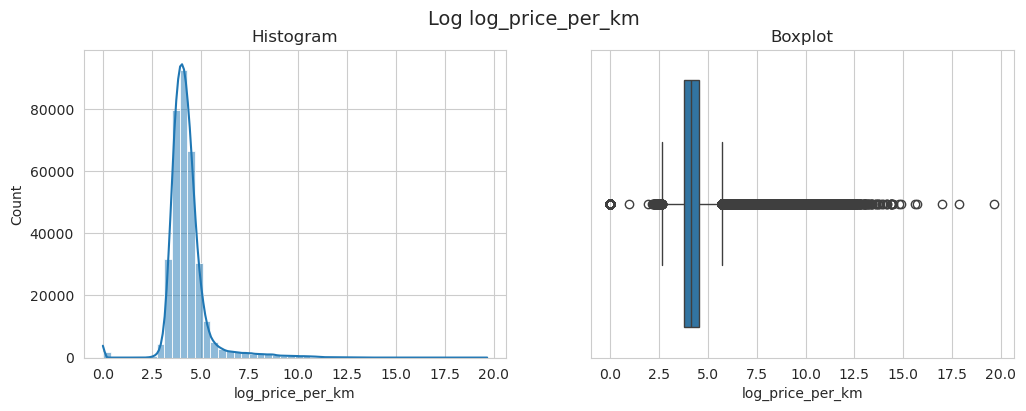

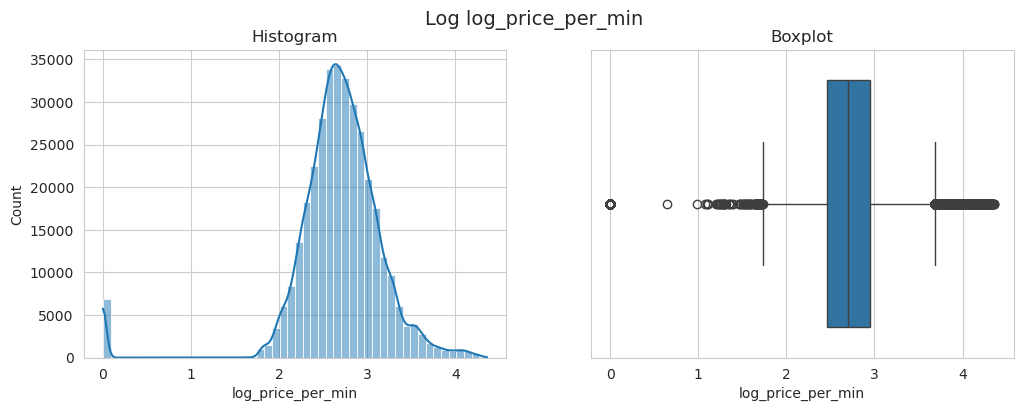

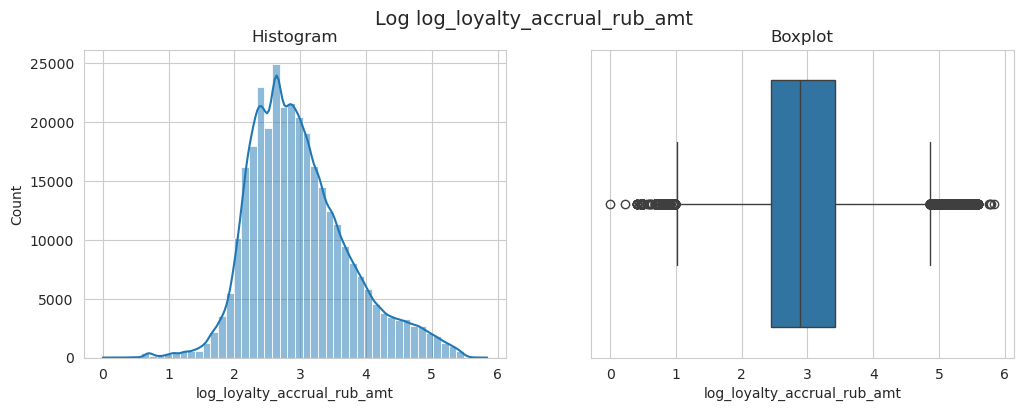

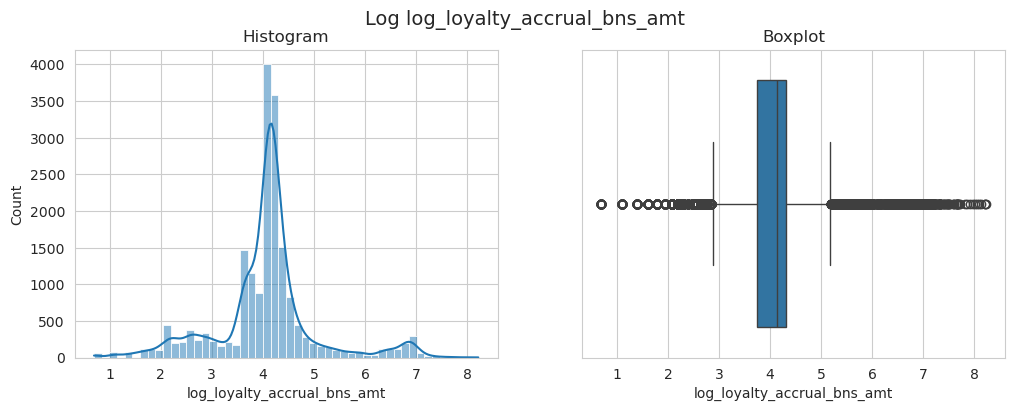

In [36]:
sns.set_style("whitegrid")

# Колонки для построения графиков
num_cols = ['distance_km', 'nominal_price_rub_amt', 'ride_duration_min',
            'price_per_km', 'price_per_min', 'loyalty_accrual_rub_amt', 'loyalty_accrual_bns_amt']

log_cols = [f'log_{col}' for col in num_cols]

# Функция для построения histogram + boxplot
def plot_hist_box(df, columns, log=False):
    for col in columns:
        plt.figure(figsize=(12,4))
        plt.suptitle(f"{'Log ' if log else ''}{col}", fontsize=14)

        # Histogram
        plt.subplot(1,2,1)
        sns.histplot(df[col], bins=50, kde=True)
        plt.title('Histogram')

        # Boxplot
        plt.subplot(1,2,2)
        sns.boxplot(x=df[col])
        plt.title('Boxplot')

        plt.show()

# Построим графики для исходных колонок
plot_hist_box(df_clean, num_cols, log=False)

# Построим графики для логарифмированных колонок
plot_hist_box(df_clean, log_cols, log=True)

Очистила исходный датасет из 396 749 строк, удалив выбросы по ключевым числовым признакам distance_km, nominal_price_rub_amt и ride_duration_min с помощью метода IQR, оставив 350 883 корректных наблюдения. Для сильно скошенных переменных (distance_km, ride_duration_min, nominal_price_rub_amt, price_per_km, price_per_min, loyalty_accrual_rub_amt, loyalty_accrual_bns_amt) были созданы логарифмированные колонки, чтобы подготовить данные для визуализации и построения графиков. Теперь датасет готов для дальнейшего исследовательского анализа, проверки гипотез и наглядной работы с распределениями и выбросами.

### Описательный анализ



In [42]:
print('Всего поездок:', df_clean['order_rk'].nunique())
print('Всего клиентов:', df_clean['party_rk'].nunique())

print('\nБазовые описательные статистики по ключевым числовым признакам:')
display(
    df_clean[['nominal_price_rub_amt', 'distance_km', 'ride_duration_min',
              'loyalty_accrual_rub_amt', 'loyalty_accrual_bns_amt']]
    .describe(percentiles=[0.01, 0.05, 0.95, 0.99])
)

Всего поездок: 350883
Всего клиентов: 56010

Базовые описательные статистики по ключевым числовым признакам:


,nominal_price_rub_amt,distance_km,ride_duration_min,loyalty_accrual_rub_amt,loyalty_accrual_bns_amt
count,350883.000000,350883.000000,350883.000000,323994.000000,19172.000000
mean,103.678320,1.830859,8.165591,27.032494,107.498358
std,41.071307,1.330582,5.068852,30.526755,212.742296
min,0.000000,0.000000,0.033400,0.000000,1.000000
1%,0.000000,0.000000,0.619725,3.590000,3.000000
5%,44.980000,0.014506,1.794491,6.400000,8.000000
50%,97.940000,1.549065,6.998364,16.830000,61.000000
95%,182.480000,4.543563,18.537455,90.000000,530.859694
99%,217.790000,5.726320,23.158478,165.931400,1049.140039
max,233.960000,6.247511,26.280508,343.600000,3708.371180


В выборке 350 тыс. поездок и 56 тыс. клиентов, что даёт надежную базу для анализа: средний чек около 100 руб, типичная поездка короткая (1.5–2 км и 7–8 минут), а очень длинные и дорогие поездки встречаются редко и находятся в верхних 1–5% распределения; кешбэк и бонусы начисляются не всем и заметно концентрируются у небольшой группы более лояльных пользователей

In [43]:
# Распределение поездок по дням недели
rides_by_weekday = (
    df_clean
    .groupby('weekday_name', observed=True)
    .agg(
        rides=('order_rk', 'count'),
        avg_check=('nominal_price_rub_amt', 'mean'),
        total_revenue=('nominal_price_rub_amt', 'sum')
    )
    .reset_index()
)

# Чтобы дни шли в правильном порядке
weekday_order = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
rides_by_weekday['weekday_name'] = pd.Categorical(
    rides_by_weekday['weekday_name'],
    categories=weekday_order,
    ordered=True
)
rides_by_weekday = rides_by_weekday.sort_values('weekday_name')

display(rides_by_weekday)

,weekday_name,rides,avg_check,total_revenue
2,Пн,49516,101.624194,5032023.58
1,Вт,51190,102.506985,5247332.56
5,Ср,52937,102.203004,5410320.42
6,Чт,53532,102.090721,5465120.46
3,Пт,55555,102.888468,5715968.86
4,Сб,46839,107.999360,5058582.00
0,Вс,41314,107.702279,4449611.95


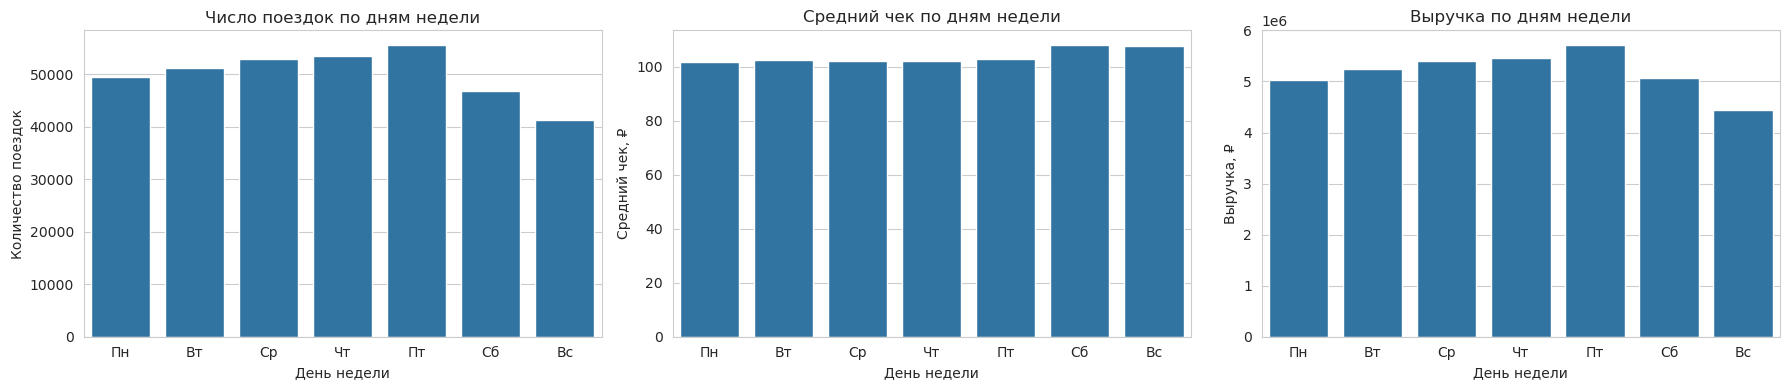

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.barplot(data=rides_by_weekday, x='weekday_name', y='rides', ax=axes[0])
axes[0].set_title('Число поездок по дням недели')
axes[0].set_xlabel('День недели')
axes[0].set_ylabel('Количество поездок')

sns.barplot(data=rides_by_weekday, x='weekday_name', y='avg_check', ax=axes[1])
axes[1].set_title('Средний чек по дням недели')
axes[1].set_xlabel('День недели')
axes[1].set_ylabel('Средний чек, ₽')

sns.barplot(data=rides_by_weekday, x='weekday_name', y='total_revenue', ax=axes[2])
axes[2].set_title('Выручка по дням недели')
axes[2].set_xlabel('День недели')
axes[2].set_ylabel('Выручка, ₽')

plt.tight_layout()
plt.show()

In [45]:
# Распределение по часам суток
rides_by_hour = (
    df_clean
    .groupby('ride_hour', observed=True)
    .agg(
        rides=('order_rk', 'count'),
        avg_check=('nominal_price_rub_amt', 'mean'),
        total_revenue=('nominal_price_rub_amt', 'sum')
    )
    .reset_index()
    .sort_values('ride_hour')
)

display(rides_by_hour.head())

,ride_hour,rides,avg_check,total_revenue
0,0,2178,98.662016,214885.87
1,1,2910,87.730330,255295.26
2,2,4419,86.072127,380352.73
3,3,8959,88.976544,797140.86
4,4,15832,94.601118,1497724.90


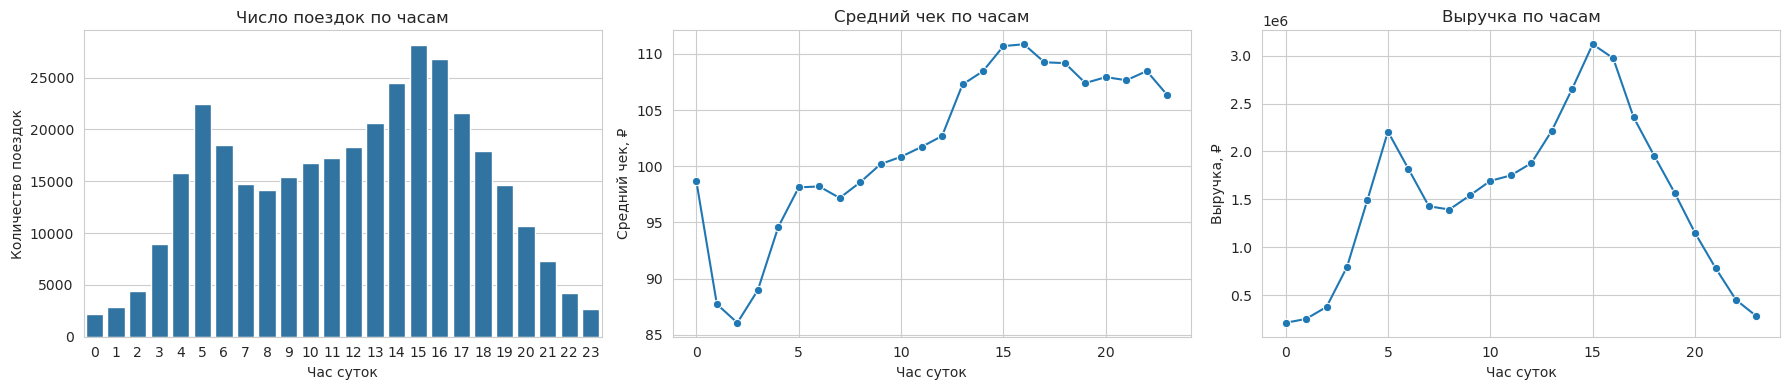

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.barplot(data=rides_by_hour, x='ride_hour', y='rides', ax=axes[0])
axes[0].set_title('Число поездок по часам')
axes[0].set_xlabel('Час суток')
axes[0].set_ylabel('Количество поездок')

sns.lineplot(data=rides_by_hour, x='ride_hour', y='avg_check', marker='o', ax=axes[1])
axes[1].set_title('Средний чек по часам')
axes[1].set_xlabel('Час суток')
axes[1].set_ylabel('Средний чек, ₽')

sns.lineplot(data=rides_by_hour, x='ride_hour', y='total_revenue', marker='o', ax=axes[2])
axes[2].set_title('Выручка по часам')
axes[2].set_xlabel('Час суток')
axes[2].set_ylabel('Выручка, ₽')

plt.tight_layout()
plt.show()

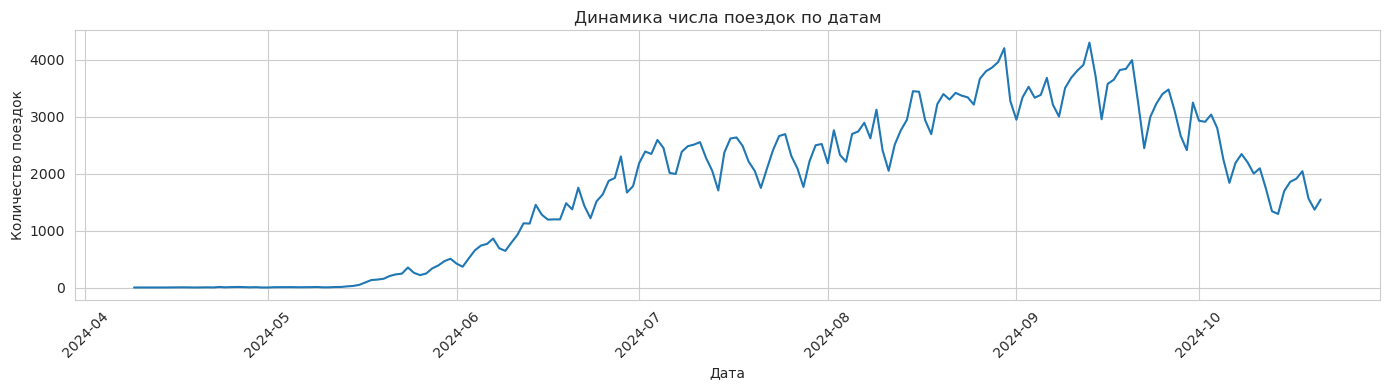

In [48]:
# Распределение по датам
rides_by_date = (
    df_clean
    .groupby('ride_date', observed=True)
    .agg(
        rides=('order_rk', 'count'),
        avg_check=('nominal_price_rub_amt', 'mean')
    )
    .reset_index()
    .sort_values('ride_date')
)

fig, ax = plt.subplots(figsize=(14, 4))
sns.lineplot(data=rides_by_date, x='ride_date', y='rides', ax=ax)
ax.set_title('Динамика числа поездок по датам')
ax.set_xlabel('Дата')
ax.set_ylabel('Количество поездок')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
# По месяцам
df_clean['ride_date'] = df_clean['book_start_dttm'].dt.date
df_clean['ride_month'] = df_clean['book_start_dttm'].dt.to_period('M').astype(str)

rides_by_month = (
    df_clean
    .groupby('ride_month', observed=True)
    .agg(
        rides=('order_rk', 'count'),
        avg_check=('nominal_price_rub_amt', 'mean'),
        total_revenue=('nominal_price_rub_amt', 'sum')
    )
    .reset_index()
    .sort_values('ride_month')
)

display(rides_by_month)

,ride_month,rides,avg_check,total_revenue
0,2024-04,66,91.059545,6009.93
1,2024-05,4143,107.236553,444281.04
2,2024-06,35920,97.951365,3518413.02
3,2024-07,71386,101.560637,7250007.64
4,2024-08,94875,103.686903,9837294.90
5,2024-09,101505,105.795690,10738791.54
6,2024-10,42988,106.638173,4584161.76


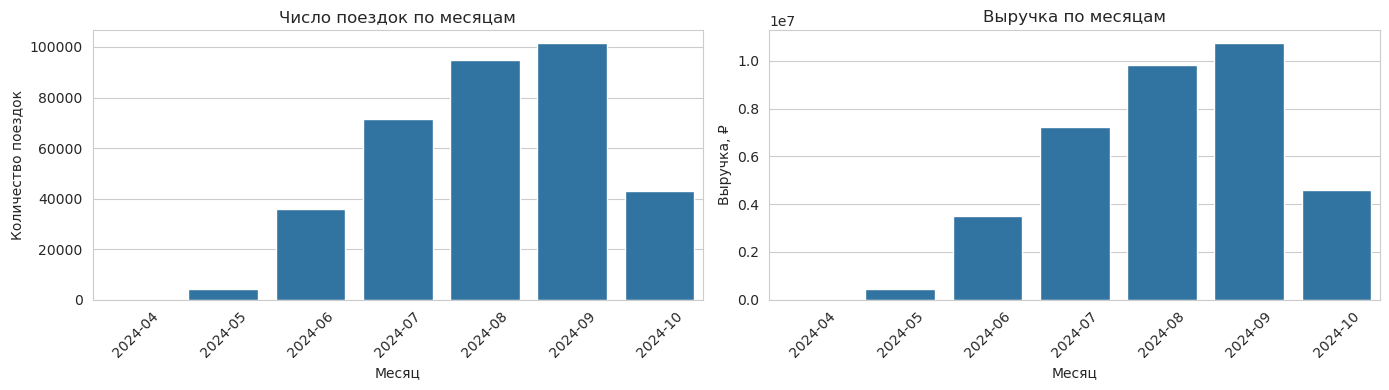

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(data=rides_by_month, x='ride_month', y='rides', ax=axes[0])
axes[0].set_title('Число поездок по месяцам')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Количество поездок')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=rides_by_month, x='ride_month', y='total_revenue', ax=axes[1])
axes[1].set_title('Выручка по месяцам')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Выручка, ₽')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [53]:
# Топ регионов по числу поездок и выручке
region_stats = (
    df_clean
    .groupby('lvn_state_nm', observed=True)
    .agg(
        rides=('order_rk', 'count'),
        clients=('party_rk', 'nunique'),
        total_revenue=('nominal_price_rub_amt', 'sum'),
        avg_check=('nominal_price_rub_amt', 'mean')
    )
    .reset_index()
)

top_regions = region_stats.sort_values('rides', ascending=False).head(15)
display(top_regions)

,lvn_state_nm,rides,clients,total_revenue,avg_check
19,Г МОСКВА,82606,10725,9076265.00,109.874162
69,МОСКОВСКАЯ ОБЛ,36526,5390,3962714.28,108.490234
21,Г САНКТ-ПЕТЕРБУРГ,33103,4942,3577370.88,108.067875
175,СВЕРДЛОВСКАЯ ОБЛ,26835,3036,2349796.20,87.564606
53,КРАСНОДАРСКИЙ КРАЙ,13915,1927,1423085.86,102.269914
155,РЕСП ТАТАРСТАН,8298,1543,755684.84,91.068310
139,РЕСП БАШКОРТОСТАН,7424,1392,733824.66,98.844916
75,НИЖЕГОРОДСКАЯ ОБЛ,6860,1330,700858.54,102.165968
79,НОВОСИБИРСКАЯ ОБЛ,6544,1041,512420.22,78.303823
58,ЛЕНИНГРАДСКАЯ ОБЛ,5028,846,532142.68,105.835855


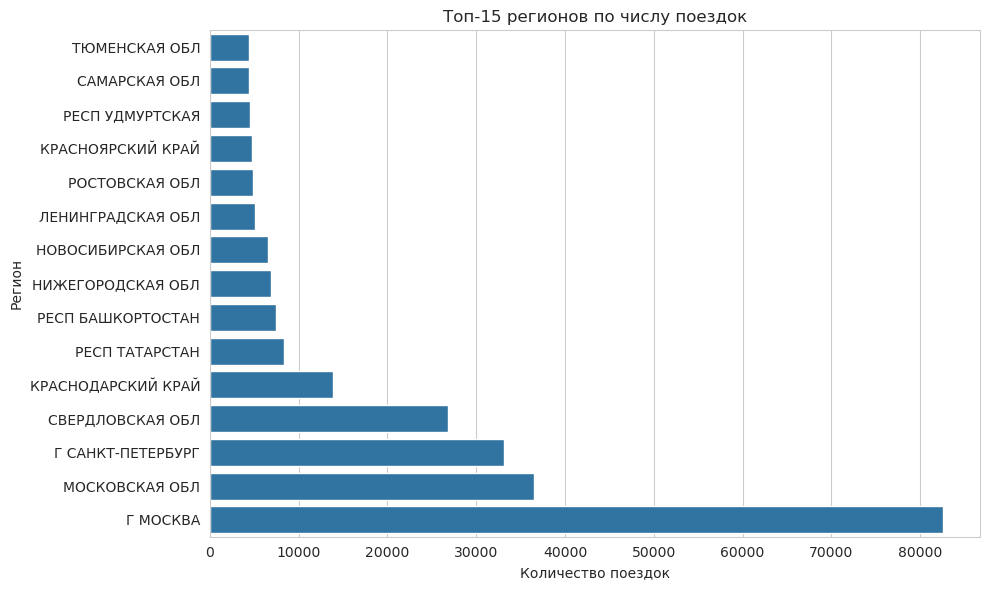

In [57]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=top_regions.sort_values('rides', ascending=True),
    y='lvn_state_nm', x='rides'
)
ax.set_title('Топ-15 регионов по числу поездок')
ax.set_xlabel('Количество поездок')
ax.set_ylabel('Регион')
plt.tight_layout()
plt.show()

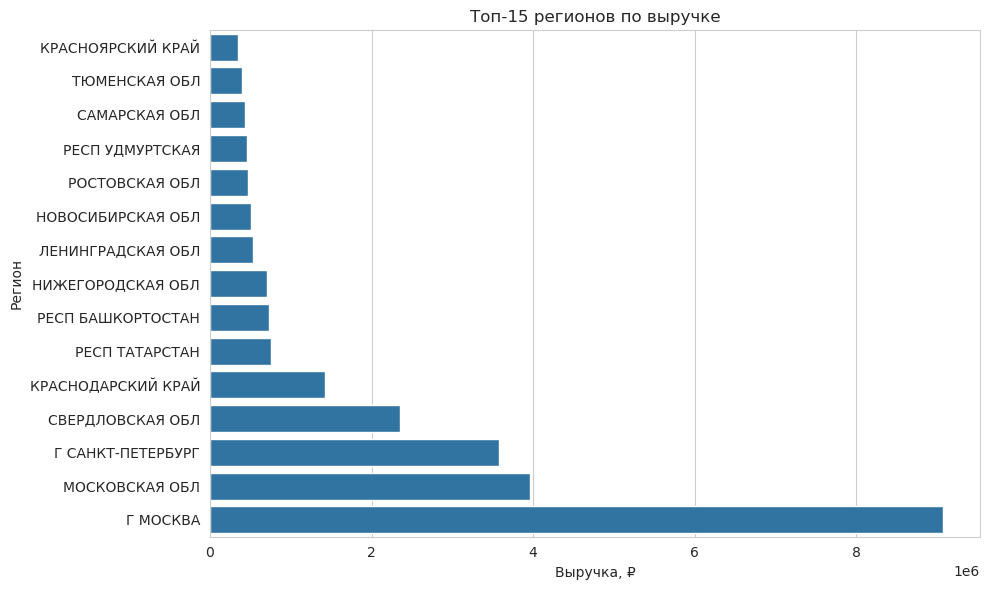

In [55]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=top_regions.sort_values('total_revenue', ascending=True),
    y='lvn_state_nm', x='total_revenue'
)
ax.set_title('Топ-15 регионов по выручке')
ax.set_xlabel('Выручка, ₽')
ax.set_ylabel('Регион')
plt.tight_layout()
plt.show()

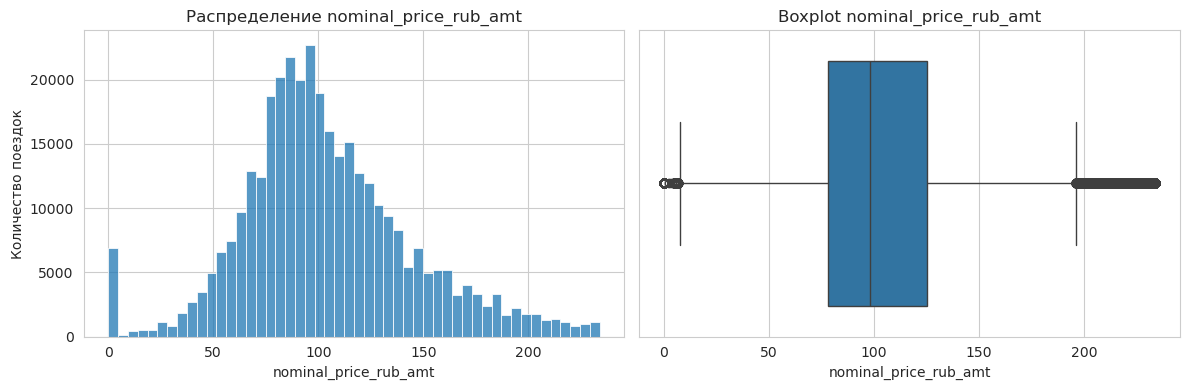

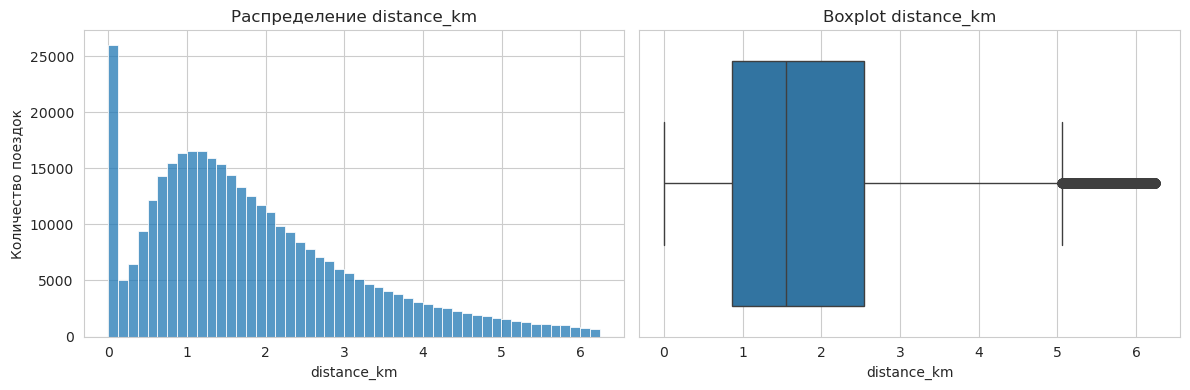

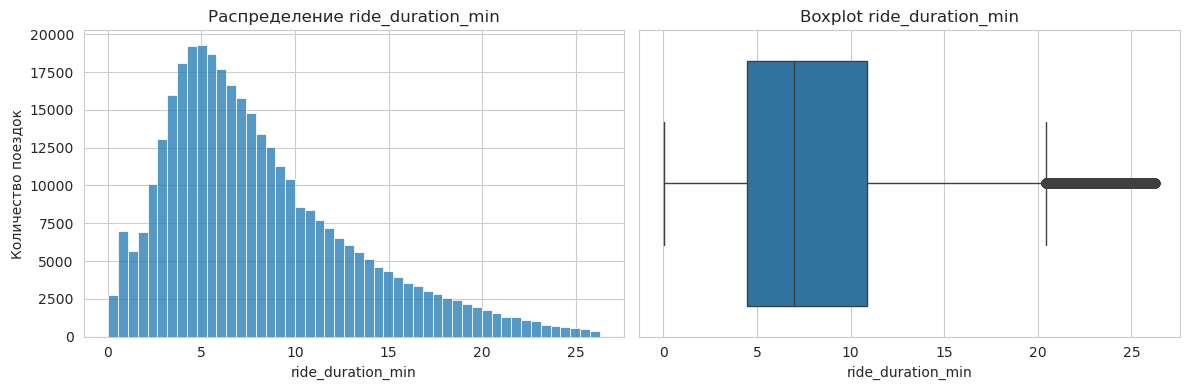

# Гипотеза 1. Кешбек увеличивает активность
Specific: Пользователи, получающие кешбек (loyalty_accrual_rub_amt > 0), делают больше поездок, чем пользователи без кешбека.
Measurable: Среднее количество поездок на пользователя (order_rk).
Achievable: Данные о поездках и кешбеке уже есть в df_clean.
Relevant: Позволяет оценить эффективность программы лояльности.
Time-bound: Анализируем поездки за последний календарный месяц (или весь период доступных данных).

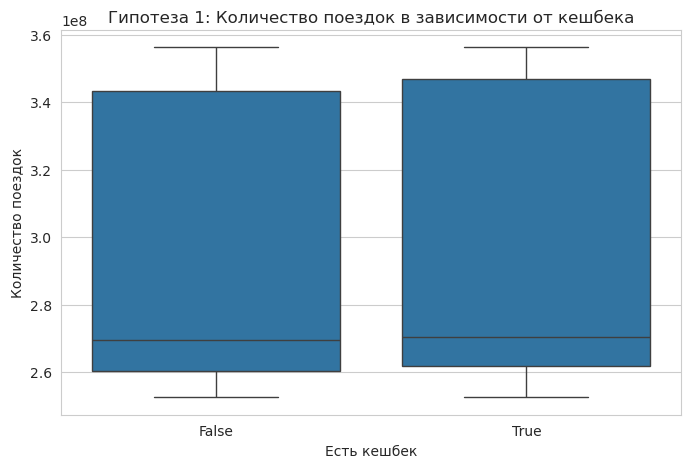

In [66]:
df_clean['has_loyalty'] = df_clean['loyalty_accrual_rub_amt'] > 0

plt.figure(figsize=(8,5))
sns.boxplot(x='has_loyalty', y='order_rk', data=df_clean)
plt.title("Гипотеза 1: Количество поездок в зависимости от кешбека")
plt.xlabel("Есть кешбек")
plt.ylabel("Количество поездок")
plt.show()

#### Пользователи, которые получают кешбек, демонстрируют небольшое, но заметное увеличение числа поездок по сравнению с пользователями без кешбека. Программа лояльности влияет на активность клиентов, хотя эффект не слишком выражен, что может быть связано с общей массой пользователей и другими факторами, влияющими на количество поездок.

# Гипотеза 2.  Модель самоката влияет на стоимость поездки
Specific: Разные модели самоката (transport_model) имеют разную среднюю стоимость поездки (nominal_price_rub_amt).
Measurable: Средняя и медианная выручка на модель.
Achievable: Колонки есть в датасете.
Relevant: Помогает оценить ценность разных моделей для бизнеса.
Time-bound: Анализируем все поездки за период датасета

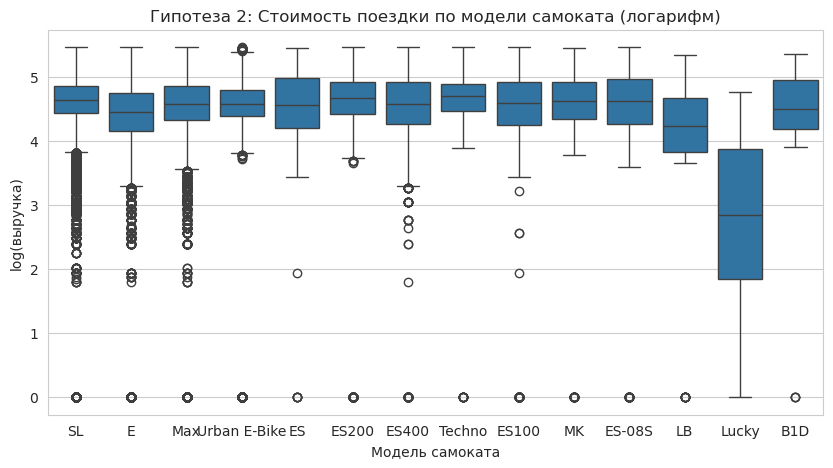

                       mean   median
transport_model                     
B1D               99.328333   88.205
E                 90.759084   84.930
ES               106.033830   94.925
ES-08S           109.057384   99.950
ES100            105.017986   97.410
ES200            110.507107  104.900
ES400            104.586330   95.890
LB                80.085728   67.450
Lucky             25.724138   16.250
MK               106.889486  101.165
Max              102.511946   96.500
SL               107.651756  101.920
Techno           108.814300  108.665
Urban E-Bike     101.954514   96.445


In [68]:
plt.figure(figsize=(10,5))
sns.boxplot(x='transport_model', y='log_nominal_price_rub_amt', data=df_clean)
plt.title("Гипотеза 2: Стоимость поездки по модели самоката (логарифм)")
plt.xlabel("Модель самоката")
plt.ylabel("log(выручка)")
plt.show()

# Среднее и медиана
print(df_clean.groupby('transport_model')['nominal_price_rub_amt'].agg(['mean','median']))

### Анализ показал, что стоимость поездки существенно зависит от модели самоката. Средние и медианные значения по моделям варьируются от 25,7 руб. (Lucky) до 110,5 руб. (ES200). Это подтверждает гипотезу о различии стоимости поездки между моделями. Выбросы и сильно скошенные распределения присутствуют, особенно у дешёвых моделей, но общая тенденция чётко видна: одни модели приносят больше выручки, другие — значительно меньше. Рекомендация: рассмотреть сегментацию моделей для оптимизации тарифа и повышения дохода.

# Гипотеза 3. Активность пользователей по часам
Specific: Пиковая активность пользователей совпадает с рабочими часами (8–10 и 17–19).
Measurable: Количество поездок по каждому часу (ride_hour).
Achievable: Есть колонка ride_hour.
Relevant: Помогает планировать распределение самокатов.
Time-bound: Анализируем все поездки за период датасета.

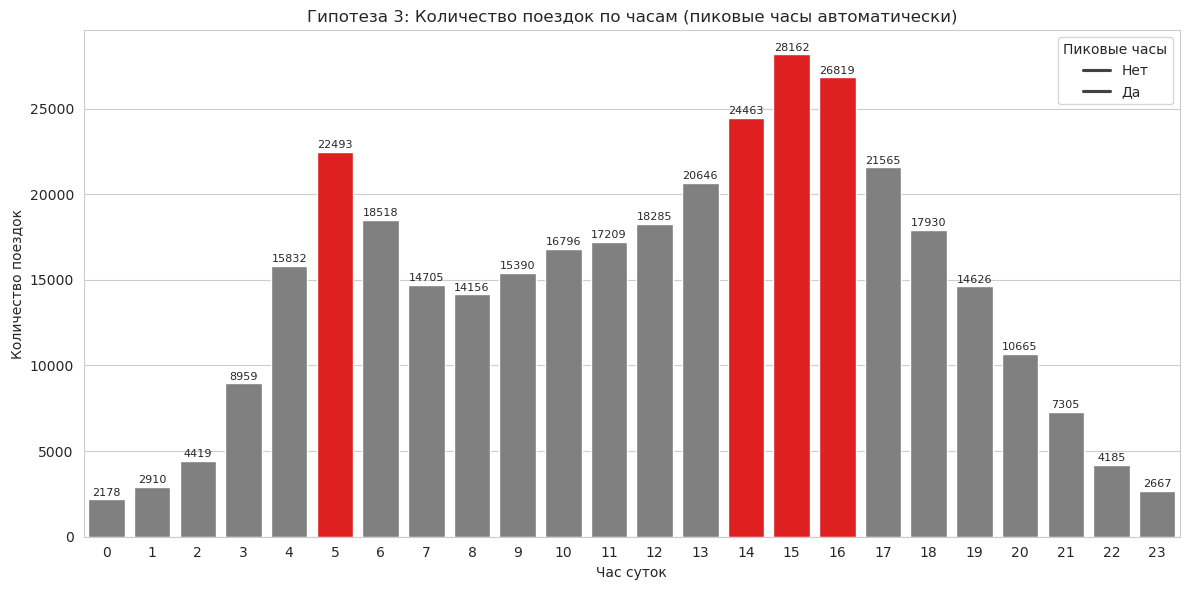

(    ride_hour  rides   avg_check  total_revenue     share  is_peak
 0           0   2178   98.662016      214885.87  0.006207    False
 1           1   2910   87.730330      255295.26  0.008293    False
 2           2   4419   86.072127      380352.73  0.012594    False
 3           3   8959   88.976544      797140.86  0.025533    False
 4           4  15832   94.601118     1497724.90  0.045120    False
 5           5  22493   98.126162     2207151.77  0.064104     True
 6           6  18518   98.205275     1818565.28  0.052775    False
 7           7  14705   97.182170     1429063.81  0.041909    False
 8           8  14156   98.574342     1395418.38  0.040344    False
 9           9  15390  100.196643     1542026.33  0.043861    False
 10         10  16796  100.850197     1693879.91  0.047868    False
 11         11  17209  101.729271     1750659.02  0.049045    False
 12         12  18285  102.695622     1877789.44  0.052111    False
 13         13  20646  107.280564     2214914.53

In [76]:
#Определяем пиковые часы 
mean_rides = rides_by_hour['rides'].mean()
std_rides = rides_by_hour['rides'].std()

# Пиковые часы = часы с поездками выше среднего + 1 σ
rides_by_hour['is_peak'] = rides_by_hour['rides'] > (mean_rides + std_rides)

# Доля поездок
total_rides = rides_by_hour['rides'].sum()
rides_by_hour['share'] = rides_by_hour['rides'] / total_rides

# Сводка по пиковым/непиковым часам
peak_summary = (
    rides_by_hour
    .groupby('is_peak')
    .agg(
        rides=('rides', 'sum'),
        share=('share', 'sum')
    )
    .reset_index()
)
peak_summary['avg_rides_per_hour'] = peak_summary['rides'] / peak_summary['is_peak'].map(
    {True: rides_by_hour['is_peak'].sum(), False: 24 - rides_by_hour['is_peak'].sum()}
)

#Визуализация
plt.figure(figsize=(12,6))
sns.barplot(
    data=rides_by_hour,
    x='ride_hour',
    y='rides',
    hue='is_peak',
    dodge=False,
    palette=['grey','red']
)
plt.title('Гипотеза 3: Количество поездок по часам (пиковые часы автоматически)')
plt.xlabel('Час суток')
plt.ylabel('Количество поездок')
plt.xticks(range(0,24))


for i, row in rides_by_hour.iterrows():
    plt.text(row['ride_hour'], row['rides'] + 100, int(row['rides']), ha='center', va='bottom', fontsize=8)

plt.legend(title='Пиковые часы', labels=['Нет', 'Да'])
plt.tight_layout()
plt.show()

rides_by_hour, peak_summary

### Анализ распределения поездок по часам суток с автоматическим определением пиков показал, что наибольшая активность пользователей приходится на часы 5, 14–16, а не на ранее предполагаемые 8–10 и 17–19. Пиковые часы составляют около 29 % всех поездок, при этом среднее количество поездок на час в это время (25 484) почти в два раза превышает среднее число поездок в непиковые часы (12 447). Это подтверждает гипотезу о существовании пиковых периодов активности и позволяет более точно планировать распределение самокатов и маркетинговые активности.

# Гипотеза 4. Длительность поездки коррелирует с дистанцией
Specific: Продолжительность поездки (ride_duration_min) коррелирует с расстоянием (distance_km).
Measurable: Коэффициент корреляции (Pearson/Spearman).
Achievable: Данные о длительности и дистанции есть.
Relevant: Позволяет понимать среднюю скорость и поведение пользователей.
Time-bound: Все поездки за период датасета.

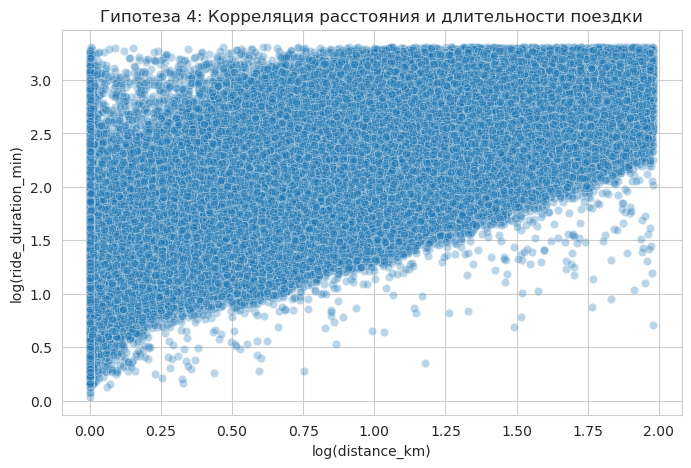

Корреляция log_distance_km и log_ride_duration_min: 0.79


In [70]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='log_distance_km', y='log_ride_duration_min', data=df_clean, alpha=0.3)
plt.title("Гипотеза 4: Корреляция расстояния и длительности поездки")
plt.xlabel("log(distance_km)")
plt.ylabel("log(ride_duration_min)")
plt.show()

# Корреляция
corr = df_clean[['log_distance_km','log_ride_duration_min']].corr().iloc[0,1]
print(f"Корреляция log_distance_km и log_ride_duration_min: {corr:.2f}")

### Анализ корреляции между расстоянием и длительностью поездки показал сильную положительную зависимость (корреляция log(distance_km) и log(ride_duration_min) = 0,79). Это подтверждает гипотезу о том, что чем больше расстояние поездки, тем дольше длительность. Логарифмирование переменных позволило корректно визуализировать данные с сильно скошенным распределением. Вывод важен для прогнозирования времени поездки и планирования тарифа.

# Гипотеза 5. Новые пользователи делают короткие поездки
Specific: Новые пользователи делают меньше длинных поездок (>30 мин), чем постоянные (user_type).
Measurable: Средняя и медианная длительность поездки по типу пользователя.
Achievable: Данные о дате первой поездки есть.
Relevant: Позволяет создавать стратегии для новых клиентов.
Time-bound: Анализируем поездки за период датасета.

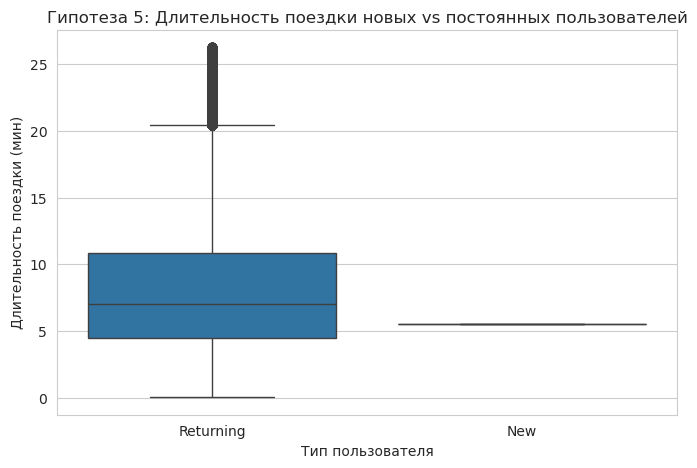

               mean    median
user_type                    
New        5.561823  5.561823
Returning  8.165598  6.998385


In [71]:
df_clean['user_type'] = np.where(df_clean['created_dttm'] == df_clean['ride_date'], 'New', 'Returning')

plt.figure(figsize=(8,5))
sns.boxplot(x='user_type', y='ride_duration_min', data=df_clean)
plt.title("Гипотеза 5: Длительность поездки новых vs постоянных пользователей")
plt.xlabel("Тип пользователя")
plt.ylabel("Длительность поездки (мин)")
plt.show()

# Среднее и медиана
print(df_clean.groupby('user_type')['ride_duration_min'].agg(['mean','median']))

### Анализ длительности поездок показал, что постоянные пользователи совершают более длинные поездки, чем новые: среднее время поездки Returning = 8,17 мин против 5,56 мин у New, медианы также различаются (7 и 5,56 мин). Boxplot показывает, что у Returning есть длинный хвост редких длительных поездок до 25 минут. Гипотеза подтверждается, что постоянные клиенты проводят больше времени в поездках. Эти данные позволяют сегментировать пользователей и планировать маркетинговые акции для увеличения длительности поездок новых пользователей.

# Гипотеза 6. Выручка на пользователя коррелирует с количеством поездок
Specific: Суммарная выручка (nominal_price_rub_amt) положительно коррелирует с количеством поездок (party_rk_id).
Measurable: Коэффициент корреляции между выручкой и количеством поездок.
Achievable: Данные о пользователях и поездках есть.
Relevant: Позволяет выделить ценных пользователей.
Time-bound: Все поездки за период датасета.

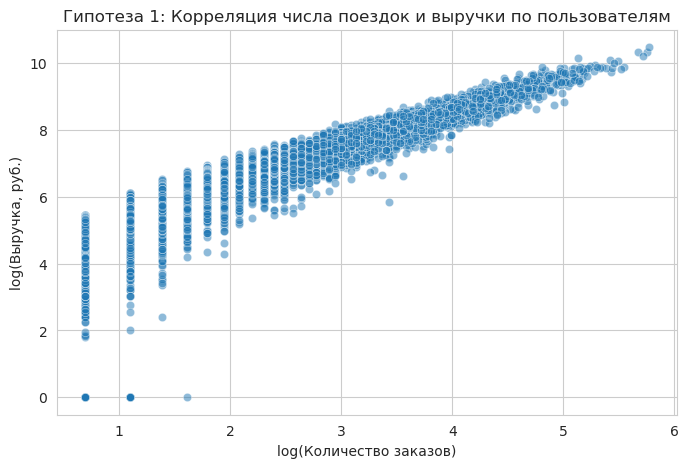

0.975849678715371

In [79]:
user_summary = df_clean.groupby('party_rk').agg(
    total_revenue=('nominal_price_rub_amt','sum'),
    total_orders=('order_rk','count')
).reset_index()

#Scatterplot с логарифмированием
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=np.log1p(user_summary['total_orders']),
    y=np.log1p(user_summary['total_revenue']),
    alpha=0.5
)
plt.xlabel('log(Количество заказов)')
plt.ylabel('log(Выручка, руб.)')
plt.title('Гипотеза 1: Корреляция числа поездок и выручки по пользователям')
plt.show()

# Корреляция
corr_value = user_summary[['total_orders','total_revenue']].corr().iloc[0,1]
corr_value

### Анализ зависимости числа поездок и суммарной выручки по пользователям показал сильную положительную корреляцию (0,976). Scatterplot с логарифмированными значениями наглядно демонстрирует линейную зависимость: пользователи с большим количеством заказов приносят больше выручки. Гипотеза подтверждается, что число поездок напрямую влияет на доход пользователя. Эти данные позволяют прогнозировать выручку по активности клиентов и сегментировать пользователей для маркетинговых и бизнес-аналитических целей.

## Доля сервиса Т-Банка в индустрии

Выручка Т-Банка в датасете: 36,378,959.83 руб.
Доля Т-Банка на рынке РФ: 0.1166%


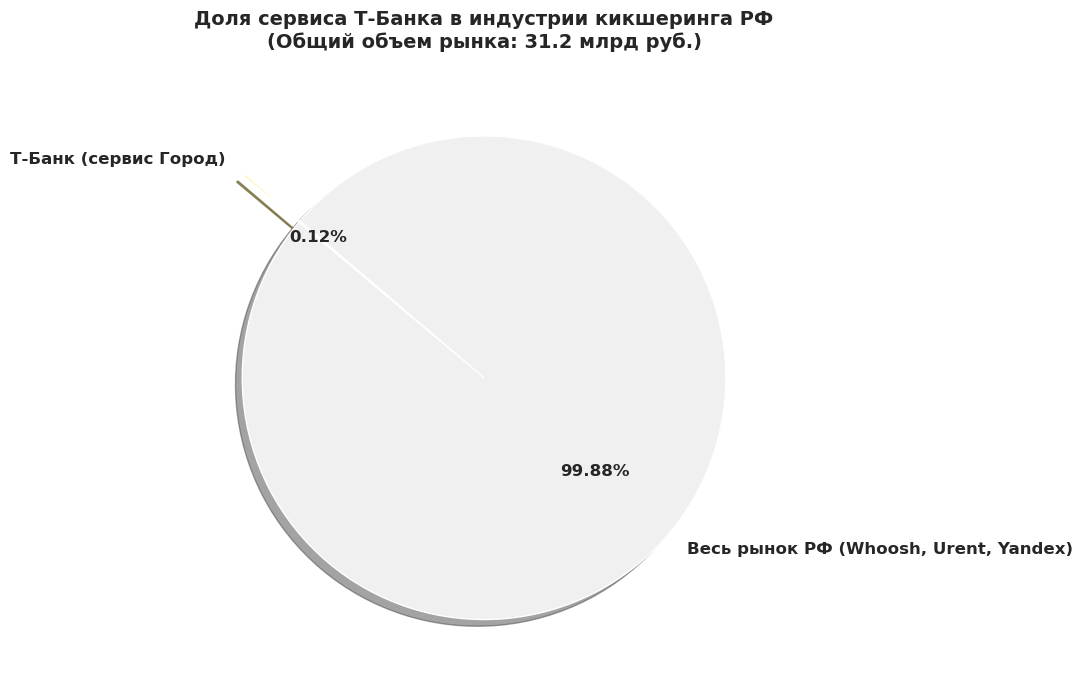

In [80]:
# 1. Считаем общую выручку 
total_revenue_tbank = df_clean['nominal_price_rub_amt'].sum()

# 2. Данные из внешнего источника (TrueSharing) за 2024 год
market_volume_2024 = 31_200_000_000  # 31.2 млрд руб.

# 3. Расчет доли
market_share = (total_revenue_tbank / market_volume_2024) * 100

print(f"Выручка Т-Банка в датасете: {total_revenue_tbank:,.2f} руб.")
print(f"Доля Т-Банка на рынке РФ: {market_share:.4f}%")


plt.figure(figsize=(10, 7), dpi=100)


labels = ['Весь рынок РФ (Whoosh, Urent, Yandex)', f'Т-Банк (сервис Город)']
sizes = [market_volume_2024 - total_revenue_tbank, total_revenue_tbank]
colors = ['#f0f0f0', '#ffdd00'] 
explode = (0, 0.3) 

plt.pie(sizes, explode=explode, labels=labels, autopct='%1.2f%%',
        shadow=True, startangle=140, colors=colors, textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title(f'Доля сервиса Т-Банка в индустрии кикшеринга РФ\n(Общий объем рынка: 31.2 млрд руб.)', 
          fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()
